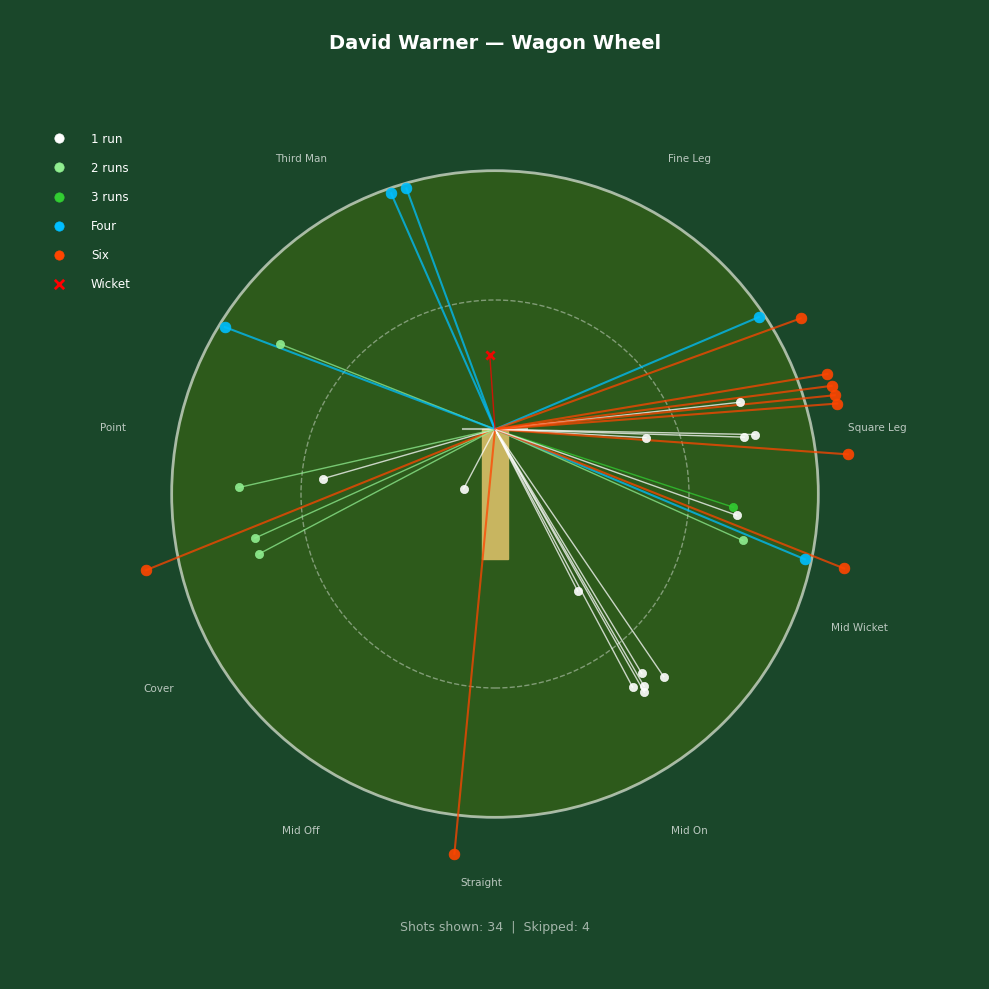

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("/Users/kushgirap/Desktop/bbl-2026-analysis/data/bbl_2026_final_coded - Sheet3.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={"batter_type": "handedness"})
df["striker"]     = df["striker"].str.strip()
df["handedness"]  = df["handedness"].str.strip()
df["is_wide"]     = df["wide"]   == "Yes"
df["is_wicket"]   = df["wicket"] == "Yes"
df["is_four"]     = df["runs_batter"] == 4
df["is_six"]      = df["runs_batter"] == 6
df["is_boundary"] = df["runs_batter"].isin([4, 6])

# ── Fielding position distance groups ─────────────────────────────────────────
DEEP = [
    "Deep Fine Leg", "Deep Backward Square Leg", "Deep Square Leg",
    "Deep Forward Square Leg", "Deep Mid Wicket", "Long On", "Long Off",
    "Deep Cover", "Deep Point", "Deep Backward Point", "Deep Forward Point",
    "Deep Third Man", "Sweeper Cover"
]
CLOSE = [
    "Silly Point", "Short Leg", "Leg Gully", "Short Mid On",
    "Short Mid Wicket", "Short Mid off", "Short Cover",
    "Keeper", "Slips", "Bowler"
]

# ── Direction angles ───────────────────────────────────────────────────────────
DIRECTION_ANGLES_RH = {
    "Fine Leg":                  30,
    "Deep Fine Leg":             30,
    "Leg Gully":                 45,
    "Short Leg":                 50,
    "Backward Square Leg":       70,
    "Deep Backward Square Leg":  70,
    "Square Leg":                80,
    "Deep Square Leg":           80,
    "Forward Square Leg":        90,
    "Deep Forward Square Leg":   90,
    "Short Mid Wicket":         110,
    "Mid Wicket":               110,
    "Deep Mid Wicket":          110,
    "Short Mid On":             150,
    "Mid On":                   150,
    "Long On":                  150,
    "Straight Hit":             182,
    "Bowler":                   184,
    "Long Off":                 210,
    "Mid Off":                  210,
    "Short Mid off":            210,
    "Extra Cover":              245,
    "Sweeper Cover":            245,
    "Short Cover":              240,
    "Cover":                    240,
    "Deep Cover":               240,
    "Cover Point":              250,
    "Forward Point":            255,
    "Deep Forward Point":       255,
    "Point":                    280,
    "Deep Point":               280,
    "Backward Point":           295,
    "Deep Backward Point":      295,
    "Gully":                    310,
    "Silly Point":              270,
    "Slips":                    320,
    "Third Man":                330,
    "Fine Third Man":           335,
    "Deep Third Man":           340,
    "Keeper":                   360,
}

def get_angle(direction, handedness):
    cricket_angle = DIRECTION_ANGLES_RH.get(direction, None)
    if cricket_angle is None:
        return None
    if handedness == "L":
        cricket_angle = 360 - cricket_angle
    return np.radians(90 - cricket_angle)

def get_color(runs, is_wicket):
    if is_wicket:  return "#FF0000"
    if runs == 6:  return "#FF4500"
    if runs == 4:  return "#00BFFF"
    if runs == 3:  return "#32CD32"
    if runs == 2:  return "#90EE90"
    if runs == 1:  return "#FFFFFF"
    return None

def distance_to_boundary(angle_rad, origin_x=0, origin_y=0.2, radius=1.0):
    dx = np.cos(angle_rad)
    dy = np.sin(angle_rad)
    a  = dx**2 + dy**2
    b  = 2 * (origin_x * dx + origin_y * dy)
    c  = origin_x**2 + origin_y**2 - radius**2
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return radius
    t1 = (-b + np.sqrt(discriminant)) / (2*a)
    t2 = (-b - np.sqrt(discriminant)) / (2*a)
    return max(t1, t2)

# ── Draw wagon wheel ───────────────────────────────────────────────────────────
def draw_wagon_wheel(data, title="Wagon Wheel"):

    np.random.seed(42)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect("equal")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axis("off")
    fig.patch.set_facecolor("#1a472a")
    ax.set_facecolor("#1a472a")

    # Field
    ax.add_patch(plt.Circle((0,0), 1.0, color="#2d5a1b", fill=True))
    ax.add_patch(plt.Circle((0,0), 0.6, color="white", fill=False,
                             linewidth=1, linestyle="--", alpha=0.4))
    ax.add_patch(plt.Circle((0,0), 1.0, color="white", fill=False,
                             linewidth=2, alpha=0.6))
    ax.add_patch(patches.Rectangle((-0.04,-0.2), 0.08, 0.4,
                                    color="#c8b560", zorder=3))

    # Crease line
    ax.plot([-0.1, 0.1], [0.2, 0.2],
            color="white", linewidth=1.5, alpha=0.6, zorder=4)

    # Field labels
    labels = {
        "Fine Leg":   30, "Square Leg":  80, "Mid Wicket": 110,
        "Mid On":    150, "Straight":   182, "Mid Off":    210,
        "Cover":     240, "Point":      280, "Third Man":  330,
    }

    # Check if all batters in this data are left handed
    # If mixed innings, default to right handed labels
    handedness_values = data["handedness"].dropna().unique()
    is_left_handed = len(handedness_values) == 1 and handedness_values[0] == "L"
    
    for label, angle_deg in labels.items():
        # Mirror angles for left handers
        if is_left_handed:
            angle_deg = 360 - angle_deg
        angle_rad = np.radians(90 - angle_deg)
        x = 1.2 * np.cos(angle_rad)
        y = 1.2 * np.sin(angle_rad)
        ax.text(x, y, label, ha="center", va="center",
                fontsize=7.5, color="white", alpha=0.7)

    ORIGIN_X = 0
    ORIGIN_Y = 0.2

    shots_drawn = 0
    skipped     = 0

    for _, row in data.iterrows():
        direction  = str(row.get("actual_direction", "")).strip()
        runs       = int(row.get("runs_batter", 0))
        handedness = str(row.get("handedness", "R")).strip()
        is_wicket  = bool(row.get("is_wicket", False))
        is_wide    = bool(row.get("is_wide", False))

        # Skip wides
        if is_wide:
            skipped += 1
            continue

        # Skip dot balls
        if runs == 0 and not is_wicket:
            continue

        # Skip if no direction
        if direction == "" or direction == "nan":
            skipped += 1
            continue

        # Get angle
        angle_rad = get_angle(direction, handedness)
        if angle_rad is None:
            skipped += 1
            continue

        # Get color
        color = get_color(runs, is_wicket)
        if color is None:
            continue

        # Step 1 — jitter angle
        jitter_angle = angle_rad + np.random.uniform(-0.08, 0.08)

        # Step 2 — calculate r using jitter_angle
        if runs == 6:
            r = distance_to_boundary(jitter_angle) * 1.1
        elif runs == 4:
            r = distance_to_boundary(jitter_angle) * 0.98
        elif direction in DEEP:
            r = distance_to_boundary(jitter_angle) * 0.78
        elif direction in CLOSE:
            r = 0.20
        else:
            r = distance_to_boundary(jitter_angle) * 0.50

        # Step 3 — jitter distance for non-boundaries
        if runs not in [4, 6]:
            r = r + np.random.uniform(-0.04, 0.04)

        # Step 4 — calculate end point
        x_end = ORIGIN_X + r * np.cos(jitter_angle)
        y_end = ORIGIN_Y + r * np.sin(jitter_angle)

        # Draw line
        lw = 1.0 if runs <= 3 else 1.5
        ax.plot([ORIGIN_X, x_end], [ORIGIN_Y, y_end],
                color=color, linewidth=lw, alpha=0.75, zorder=4)

        # Draw dot
        sz     = 35 if runs <= 3 else 60
        marker = "x" if is_wicket else "o"
        ax.scatter(x_end, y_end, c=color, s=sz,
                   marker=marker, zorder=5, alpha=0.9,
                   linewidths=2 if is_wicket else 0.5)

        shots_drawn += 1

    # Legend
    legend_items = [
        ("#FFFFFF", "o", "1 run"),
        ("#90EE90", "o", "2 runs"),
        ("#32CD32", "o", "3 runs"),
        ("#00BFFF", "o", "Four"),
        ("#FF4500", "o", "Six"),
        ("#FF0000", "x", "Wicket"),
    ]
    for i, (col, mkr, lbl) in enumerate(legend_items):
        y_pos = 1.1 - i * 0.09
        ax.scatter([-1.35], [y_pos], c=col, s=45, marker=mkr,
                   zorder=6, linewidths=2 if mkr == "x" else 0.5)
        ax.text(-1.25, y_pos, lbl, color="white",
                fontsize=8.5, va="center")

    ax.text(0, 1.38, title, ha="center", fontsize=14,
            color="white", fontweight="bold")
    ax.text(0, -1.35,
            f"Shots shown: {shots_drawn}  |  Skipped: {skipped}",
            ha="center", fontsize=9, color="white", alpha=0.6)

    plt.tight_layout()
    plt.show()

# ── Run ───────────────────────────────────────────────────────────────────────
draw_wagon_wheel(
    df[df["striker"] == "Steve Smith"],
    title="David Warner — Wagon Wheel"
)

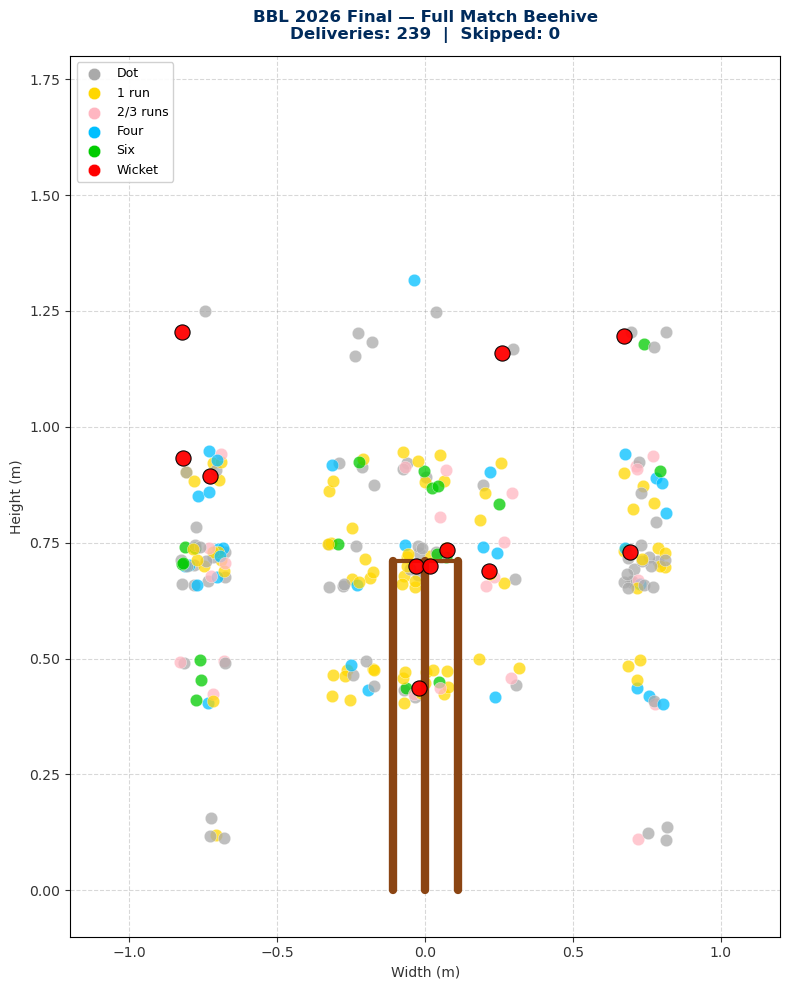

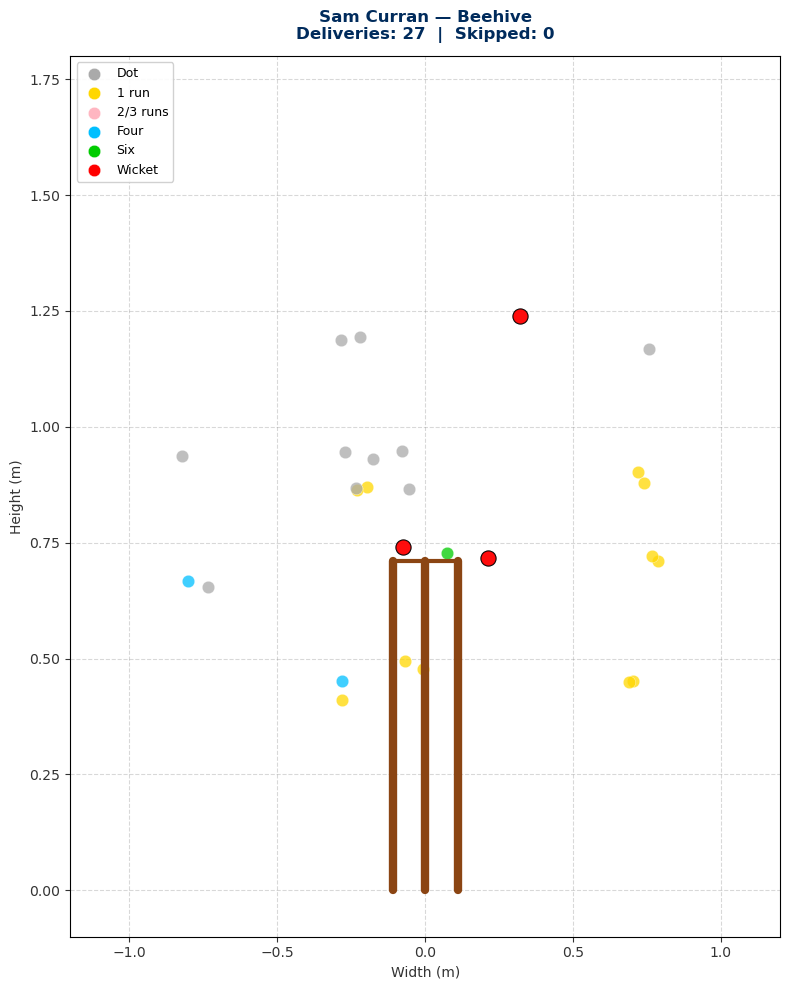

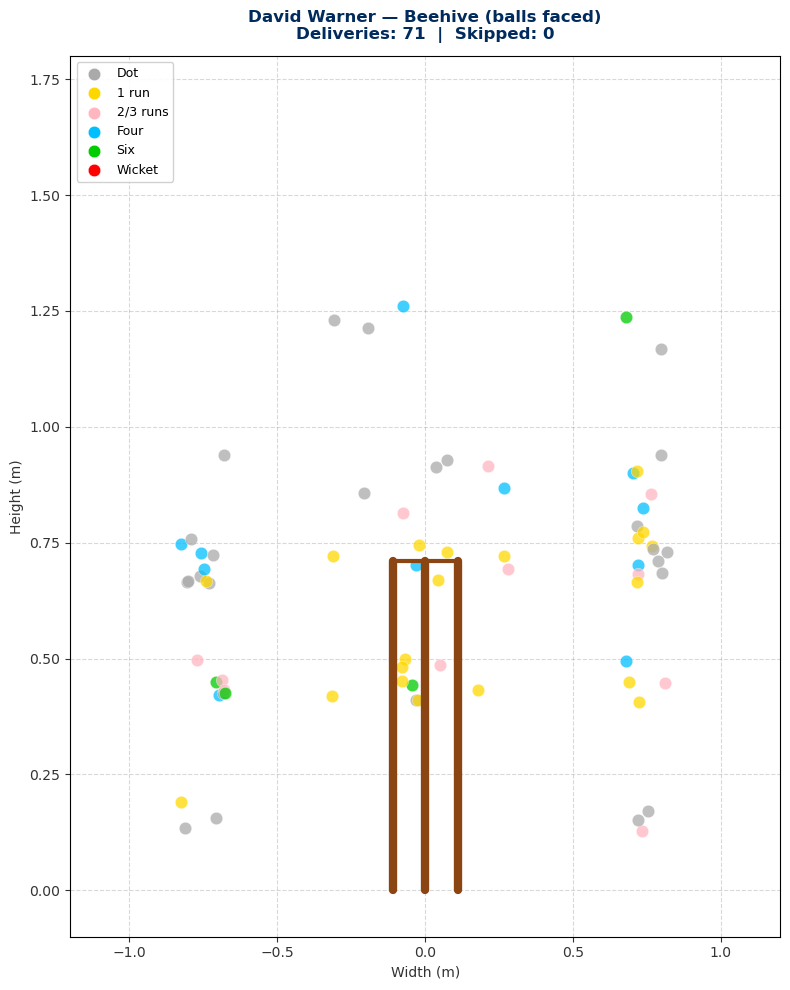

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# ── Load data ─────────────────────────────────────────────────────────────────
# df = pd.read_csv("data/bbl_2026_final_coded - Sheet3.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={"batter_type": "handedness"})
df["striker"]    = df["striker"].str.strip()
df["handedness"] = df["handedness"].str.strip()
df["is_wide"]    = df["wide"]   == "Yes"
df["is_wicket"]  = df["wicket"] == "Yes"
df["is_four"]    = df["runs_batter"] == 4
df["is_six"]     = df["runs_batter"] == 6

# ── Mappings ──────────────────────────────────────────────────────────────────
LINE_TO_X = {
    "Outside Off": -0.75, "Off": -0.25, "Middle": 0.0,
    "Leg": 0.25, "Outside Leg": 0.75,
}
LENGTH_TO_Y = {
    "Beamer": 1.30, "Bouncer": 1.20, "Short of length": 0.90,
    "Good Length": 0.70, "Full": 0.45, "Yorker": 0.15, "FT": 0.80,
}

def get_color(runs, is_wicket):
    if is_wicket:        return "#FF0000"   # red
    if runs == 6:        return "#00CC00"   # green
    if runs == 4:        return "#00BFFF"   # blue
    if runs in [2, 3]:   return "#FFB6C1"   # pink
    if runs == 1:        return "#FFD700"   # yellow
    return "#AAAAAA"                        # grey for dot

# ── Draw beehive ──────────────────────────────────────────────────────────────
def draw_beehive(data, title="Beehive"):

    np.random.seed(42)

    fig, ax = plt.subplots(figsize=(8, 10))
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.1, 1.8)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Grid
    ax.grid(True, linestyle="--", alpha=0.3, color="grey", zorder=0)
    ax.set_xlabel("Width (m)", fontsize=10, color="#333333")
    ax.set_ylabel("Height (m)", fontsize=10, color="#333333")
    ax.tick_params(colors="#333333")

    # Stumps
    for sx in [-0.11, 0, 0.11]:
        ax.plot([sx, sx], [0, 0.71],
                color="#8B4513", linewidth=6,
                zorder=5, solid_capstyle="round")
    ax.plot([-0.11, 0],   [0.71, 0.71], color="#8B4513", linewidth=3, zorder=5)
    ax.plot([0,    0.11], [0.71, 0.71], color="#8B4513", linewidth=3, zorder=5)

    # ── Plot all deliveries ───────────────────────────────────────────────────
    plotted = 0
    skipped = 0

    for _, row in data.iterrows():
        line      = str(row.get("line",   "")).strip()
        length    = str(row.get("length", "")).strip()
        runs      = int(row.get("runs_batter", 0))
        is_wicket = bool(row.get("is_wicket", False))

        # Skip if line or length not in mapping
        if line not in LINE_TO_X or length not in LENGTH_TO_Y:
            skipped += 1
            continue

        # Get coordinates
        x = LINE_TO_X[line]
        y = LENGTH_TO_Y[length]

# Mirror x for left handed batters
# Outside off for a lefty is on the opposite side
        handedness = str(row.get("handedness", "R")).strip()
        if handedness == "L":
            x = -x

# Jitter AFTER mirroring
        x = x + np.random.uniform(-0.08, 0.08)
        y = y + np.random.uniform(-0.05, 0.05)

        color = get_color(runs, is_wicket)

        # Wickets slightly larger with black edge
        if is_wicket:
            ax.scatter(x, y, c=color, s=120,
                       zorder=6, alpha=0.95,
                       edgecolors="black", linewidths=0.8)
        else:
            ax.scatter(x, y, c=color, s=80,
                       zorder=4, alpha=0.75,
                       edgecolors="white", linewidths=0.3)
        plotted += 1

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_items = [
        ("#AAAAAA", "Dot"),
        ("#FFD700", "1 run"),
        ("#FFB6C1", "2/3 runs"),
        ("#00BFFF", "Four"),
        ("#00CC00", "Six"),
        ("#FF0000", "Wicket"),
    ]
    for i, (col, lbl) in enumerate(legend_items):
        ax.scatter([], [], c=col, s=80,
                   label=lbl, edgecolors="white", linewidths=0.3)
    ax.legend(loc="upper left", fontsize=9,
              framealpha=0.9, edgecolor="#cccccc")

    # Title and stats
    ax.set_title(f"{title}\nDeliveries: {plotted}  |  Skipped: {skipped}",
                 fontsize=12, fontweight="bold",
                 color="#002B5C", pad=12)

    plt.tight_layout()
    plt.show()

# ── Run ───────────────────────────────────────────────────────────────────────

# Full match
draw_beehive(df, title="BBL 2026 Final — Full Match Beehive")

# Single bowler
draw_beehive(
    df[df["bowler"] == "Sam Curran"],
    title="Sam Curran — Beehive"
)

# Single batter
draw_beehive(
    df[df["striker"] == "David Warner"],
    title="David Warner — Beehive (balls faced)"
)

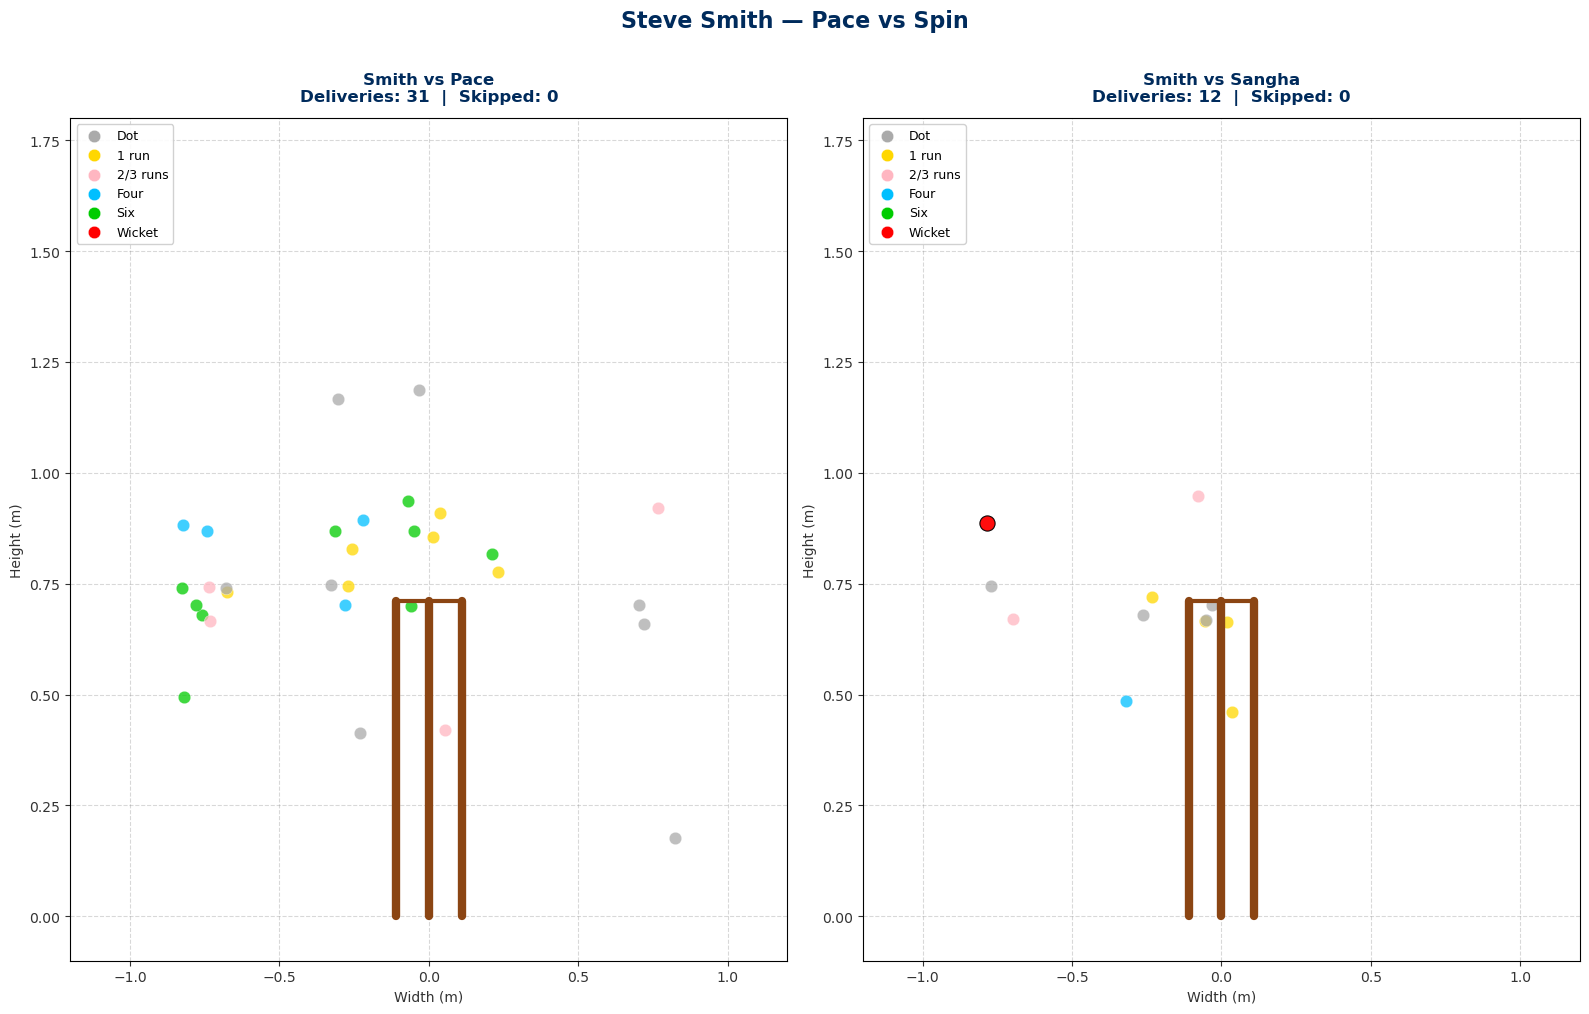

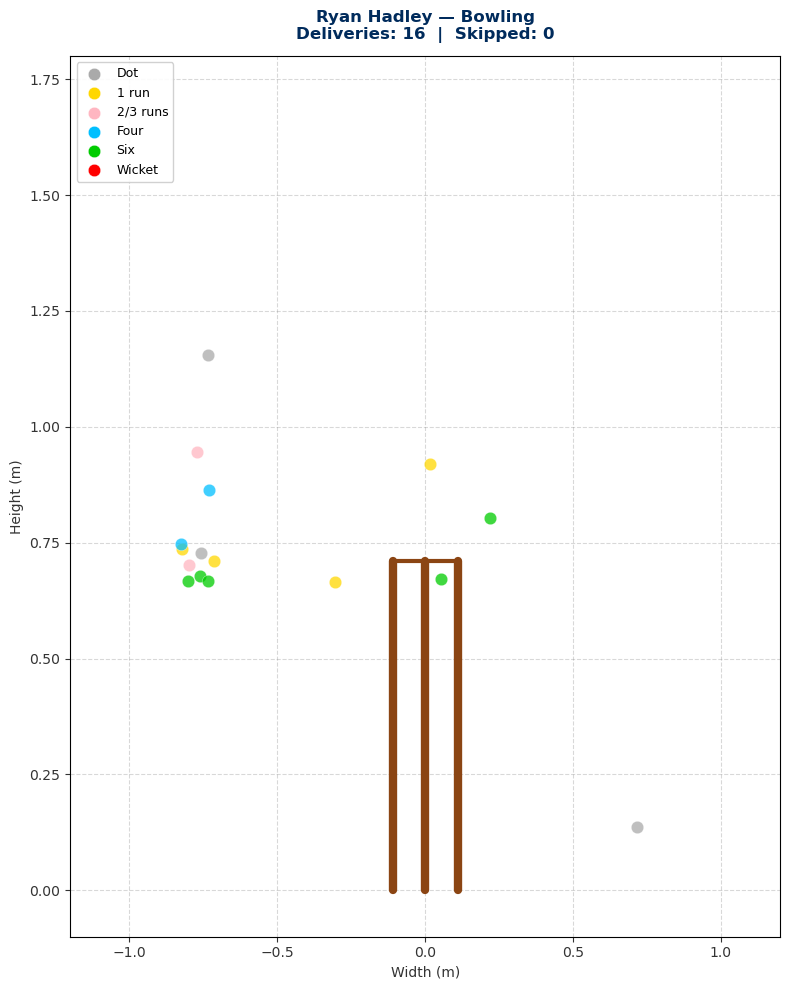

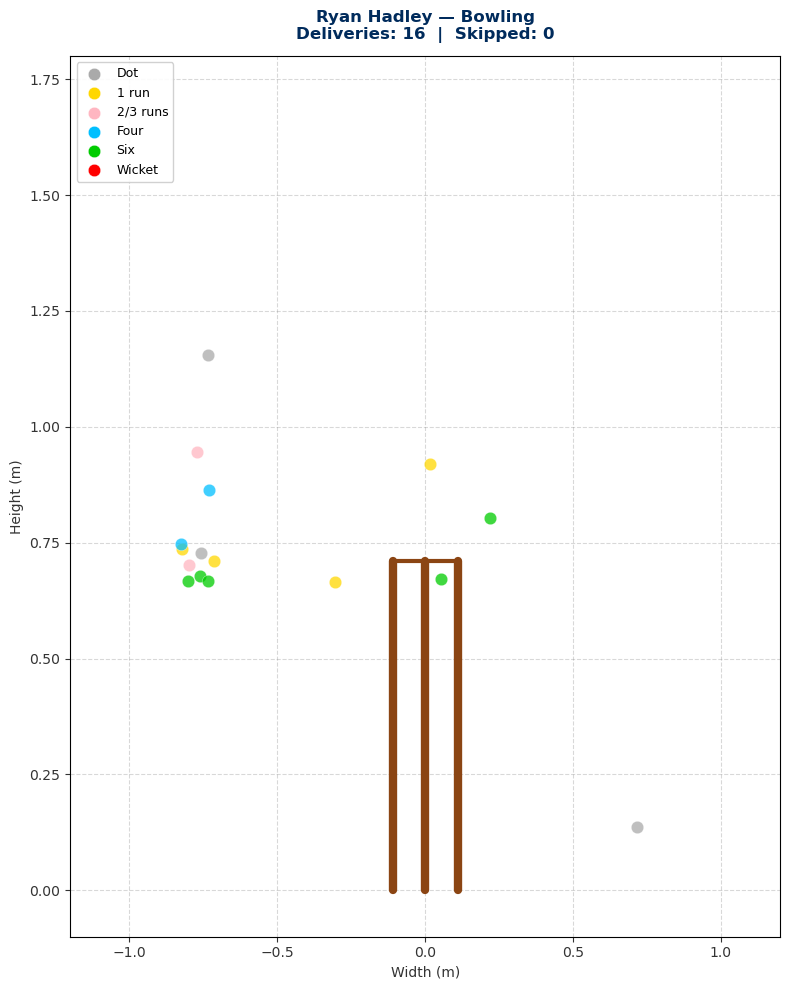

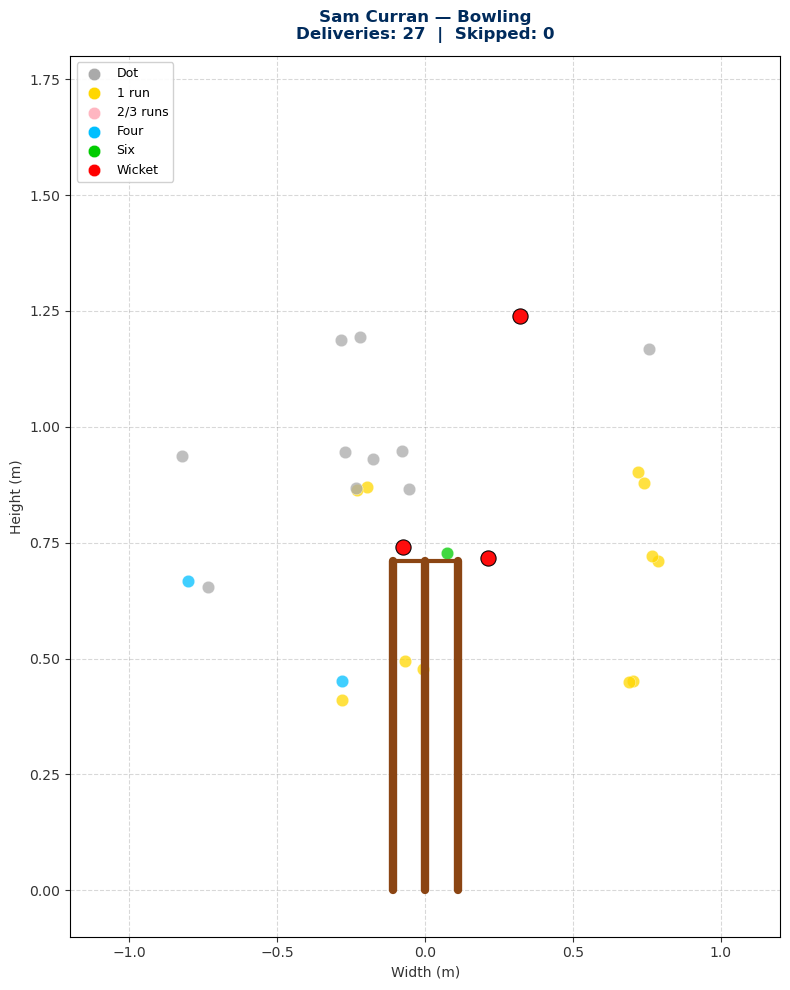

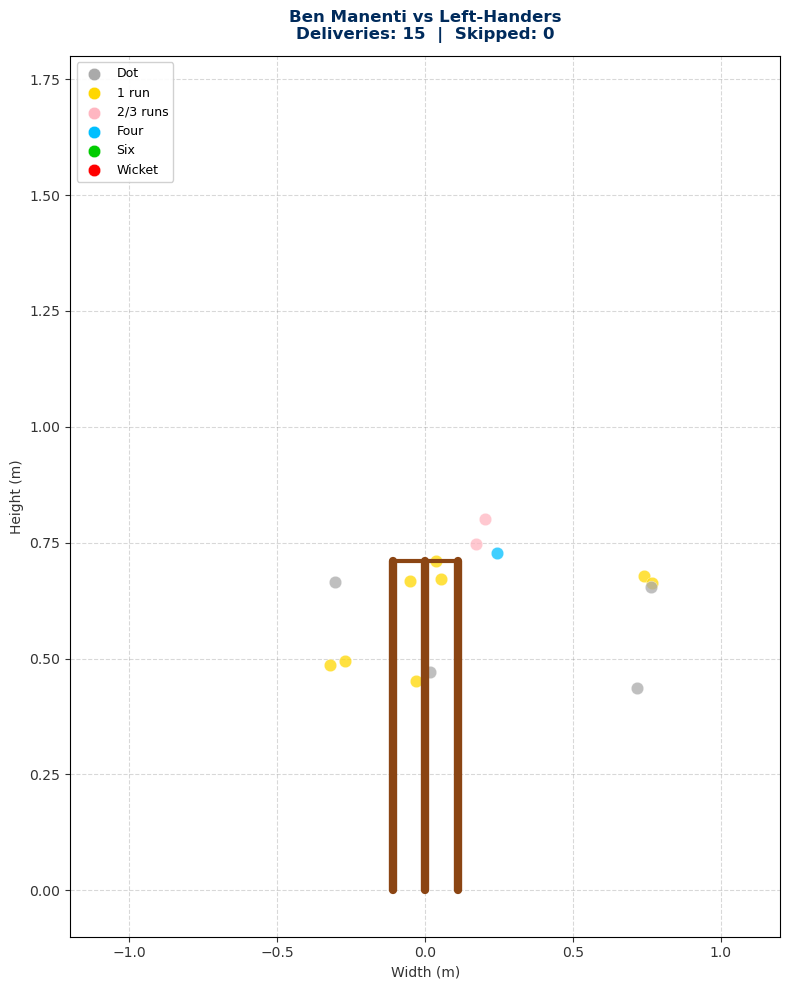

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("/Users/kushgirap/Desktop/bbl-2026-analysis/data/bbl_2026_final_coded - Sheet3.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={"batter_type": "handedness"})
df["striker"]    = df["striker"].str.strip()
df["handedness"] = df["handedness"].str.strip()
df["is_wide"]    = df["wide"]   == "Yes"
df["is_wicket"]  = df["wicket"] == "Yes"
df["is_four"]    = df["runs_batter"] == 4
df["is_six"]     = df["runs_batter"] == 6

# ── Mappings ──────────────────────────────────────────────────────────────────
LINE_TO_X = {
    "Outside Off": -0.75, "Off": -0.25, "Middle": 0.0,
    "Leg": 0.25, "Outside Leg": 0.75,
}
LENGTH_TO_Y = {
    "Beamer": 1.30, "Bouncer": 1.20, "Short of length": 0.90,
    "Good Length": 0.70, "Full": 0.45, "Yorker": 0.15, "FT": 0.80,
}

def get_color(runs, is_wicket):
    if is_wicket:        return "#FF0000"
    if runs == 6:        return "#00CC00"
    if runs == 4:        return "#00BFFF"
    if runs in [2, 3]:   return "#FFB6C1"
    if runs == 1:        return "#FFD700"
    return "#AAAAAA"

# ── Draw beehive ──────────────────────────────────────────────────────────────
def draw_beehive(data, title="Beehive", ax=None):

    np.random.seed(42)

    standalone = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 10))
        standalone = True

    fig = ax.get_figure()
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.1, 1.8)
    ax.set_facecolor("white")

    # Grid
    ax.grid(True, linestyle="--", alpha=0.3, color="grey", zorder=0)
    ax.set_xlabel("Width (m)", fontsize=10, color="#333333")
    ax.set_ylabel("Height (m)", fontsize=10, color="#333333")
    ax.tick_params(colors="#333333")

    # Stumps
    for sx in [-0.11, 0, 0.11]:
        ax.plot([sx, sx], [0, 0.71],
                color="#8B4513", linewidth=6,
                zorder=5, solid_capstyle="round")
    ax.plot([-0.11, 0],   [0.71, 0.71], color="#8B4513", linewidth=3, zorder=5)
    ax.plot([0,    0.11], [0.71, 0.71], color="#8B4513", linewidth=3, zorder=5)

    # ── Plot deliveries ───────────────────────────────────────────────────────
    plotted = 0
    skipped = 0

    for _, row in data.iterrows():
        line      = str(row.get("line",   "")).strip()
        length    = str(row.get("length", "")).strip()
        runs      = int(row.get("runs_batter", 0))
        is_wicket = bool(row.get("is_wicket", False))

        if line not in LINE_TO_X or length not in LENGTH_TO_Y:
            skipped += 1
            continue

        x = LINE_TO_X[line]
        y = LENGTH_TO_Y[length]

        handedness = str(row.get("handedness", "R")).strip()
        if handedness == "L":
            x = -x

        x = x + np.random.uniform(-0.08, 0.08)
        y = y + np.random.uniform(-0.05, 0.05)

        color = get_color(runs, is_wicket)

        if is_wicket:
            ax.scatter(x, y, c=color, s=120,
                       zorder=6, alpha=0.95,
                       edgecolors="black", linewidths=0.8)
        else:
            ax.scatter(x, y, c=color, s=80,
                       zorder=4, alpha=0.75,
                       edgecolors="white", linewidths=0.3)
        plotted += 1

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_items = [
        ("#AAAAAA", "Dot"),
        ("#FFD700", "1 run"),
        ("#FFB6C1", "2/3 runs"),
        ("#00BFFF", "Four"),
        ("#00CC00", "Six"),
        ("#FF0000", "Wicket"),
    ]
    for col, lbl in legend_items:
        ax.scatter([], [], c=col, s=80,
                   label=lbl, edgecolors="white", linewidths=0.3)
    ax.legend(loc="upper left", fontsize=9,
              framealpha=0.9, edgecolor="#cccccc")

    ax.set_title(f"{title}\nDeliveries: {plotted}  |  Skipped: {skipped}",
                 fontsize=12, fontweight="bold",
                 color="#002B5C", pad=12)

    if standalone:
        plt.tight_layout()
        plt.show()

# ── Filters ───────────────────────────────────────────────────────────────────
smith_vs_pace = df[
    (df["striker"] == "Steve Smith") &
    (df["type_of_bowler"].str.contains("Fast|Medium", case=False, na=False))
]

smith_vs_sangha = df[
    (df["striker"] == "Steve Smith") &
    (df["bowler"] == "Tanveer Sangha")
]

hadley = df[df["bowler"] == "Ryan Hadley"]

# ── Visual 1 & 2 — Smith vs Pace vs Sangha (side by side) ────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor("white")
draw_beehive(smith_vs_pace,   title="Smith vs Pace",   ax=ax1)
draw_beehive(smith_vs_sangha, title="Smith vs Sangha", ax=ax2)
plt.suptitle("Steve Smith — Pace vs Spin", fontsize=16,
             fontweight="bold", color="#002B5C", y=1.01)
plt.tight_layout()
# plt.savefig("smith_pace_vs_sangha.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Visual 3 — Hadley beehive ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 10))
fig.patch.set_facecolor("white")
draw_beehive(hadley, title="Ryan Hadley — Bowling", ax=ax)
plt.tight_layout()
# plt.savefig("hadley_beehive.png", dpi=150, bbox_inches="tight")
plt.show()

# Hadley
hadley = df[df["bowler"] == "Ryan Hadley"]
draw_beehive(hadley, title="Ryan Hadley — Bowling")

# Curran
curran_bowling = df[df["bowler"] == "Sam Curran"]
draw_beehive(curran_bowling, title="Sam Curran — Bowling")

# Manenti left handers
manenti_vs_lefties = df[
    (df["bowler"] == "Ben Manenti") &
    (df["handedness"] == "L")
]
draw_beehive(manenti_vs_lefties, title="Ben Manenti vs Left-Handers")

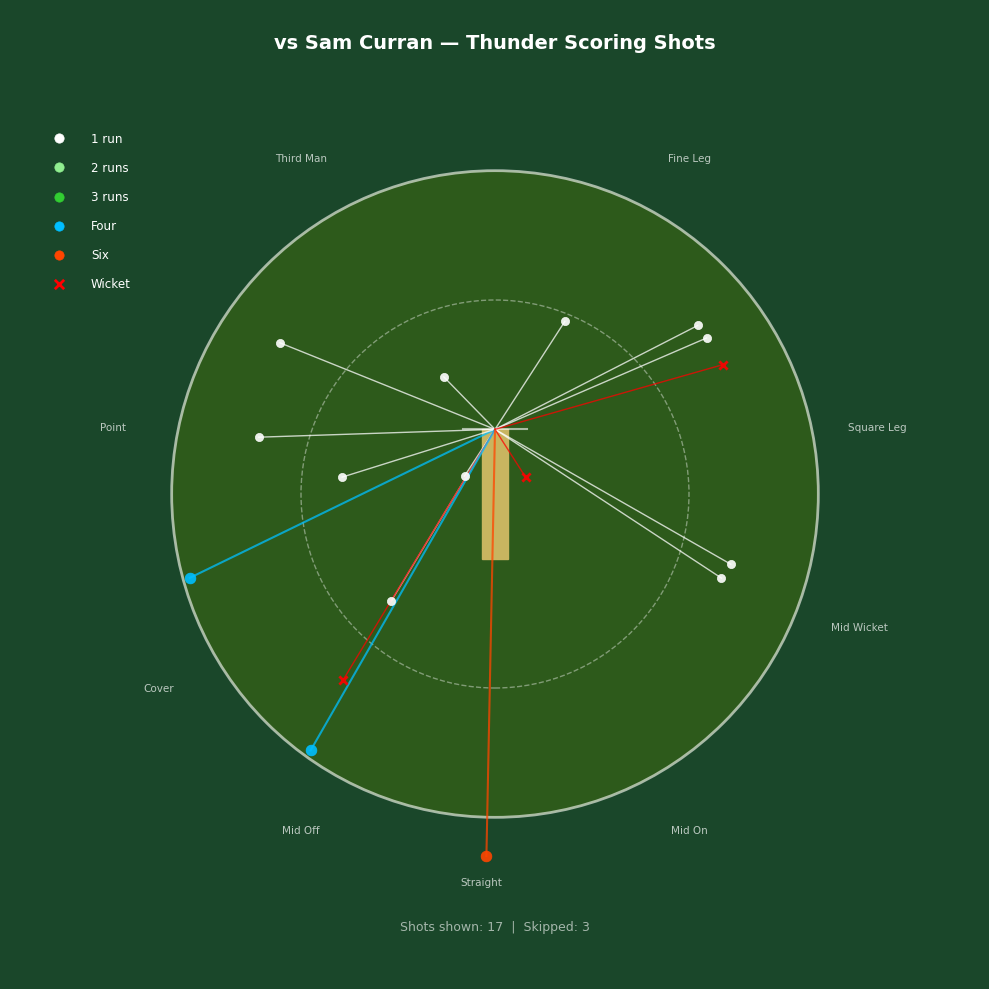

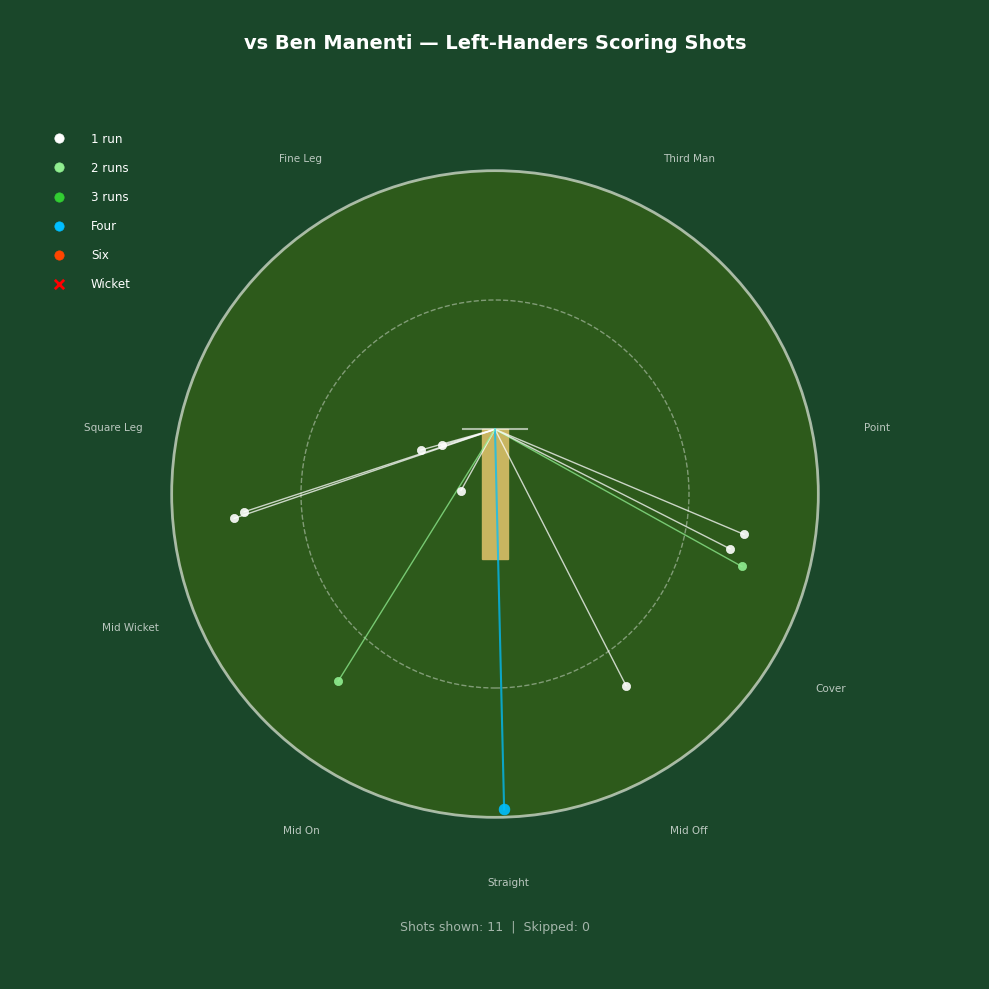

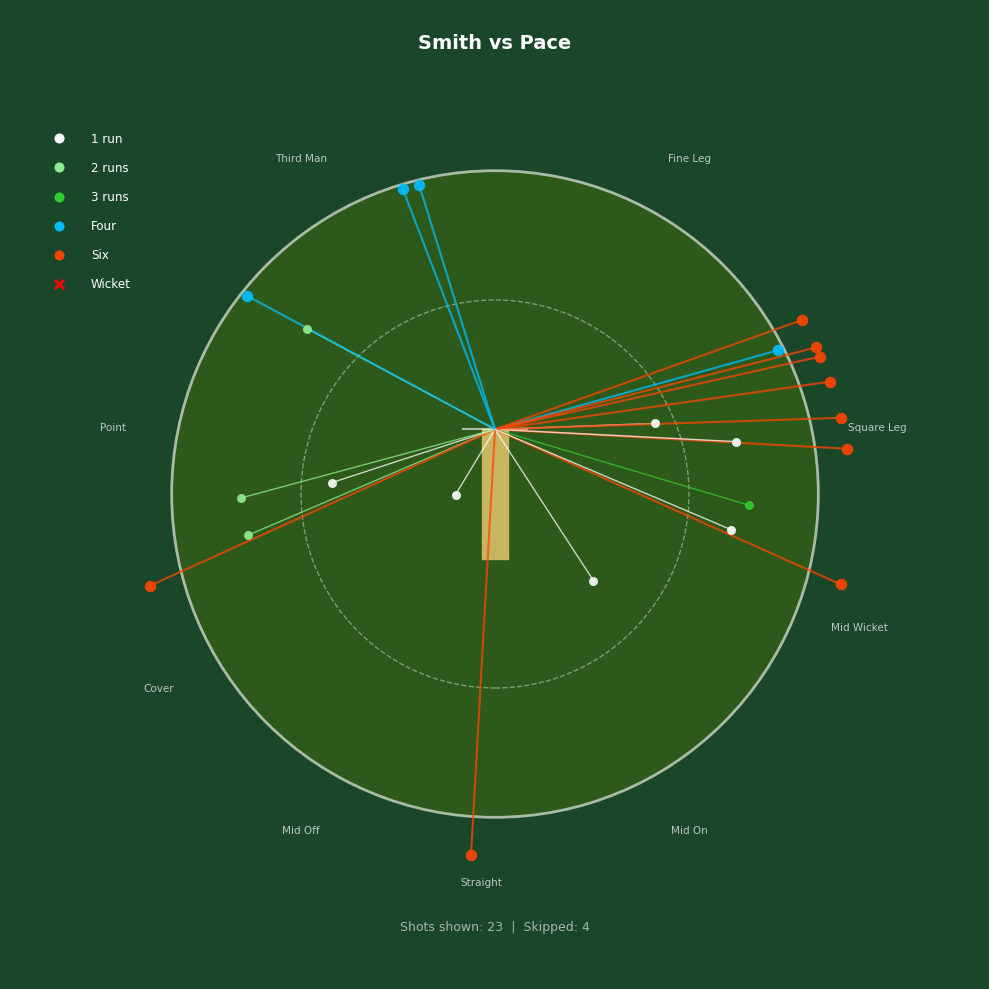

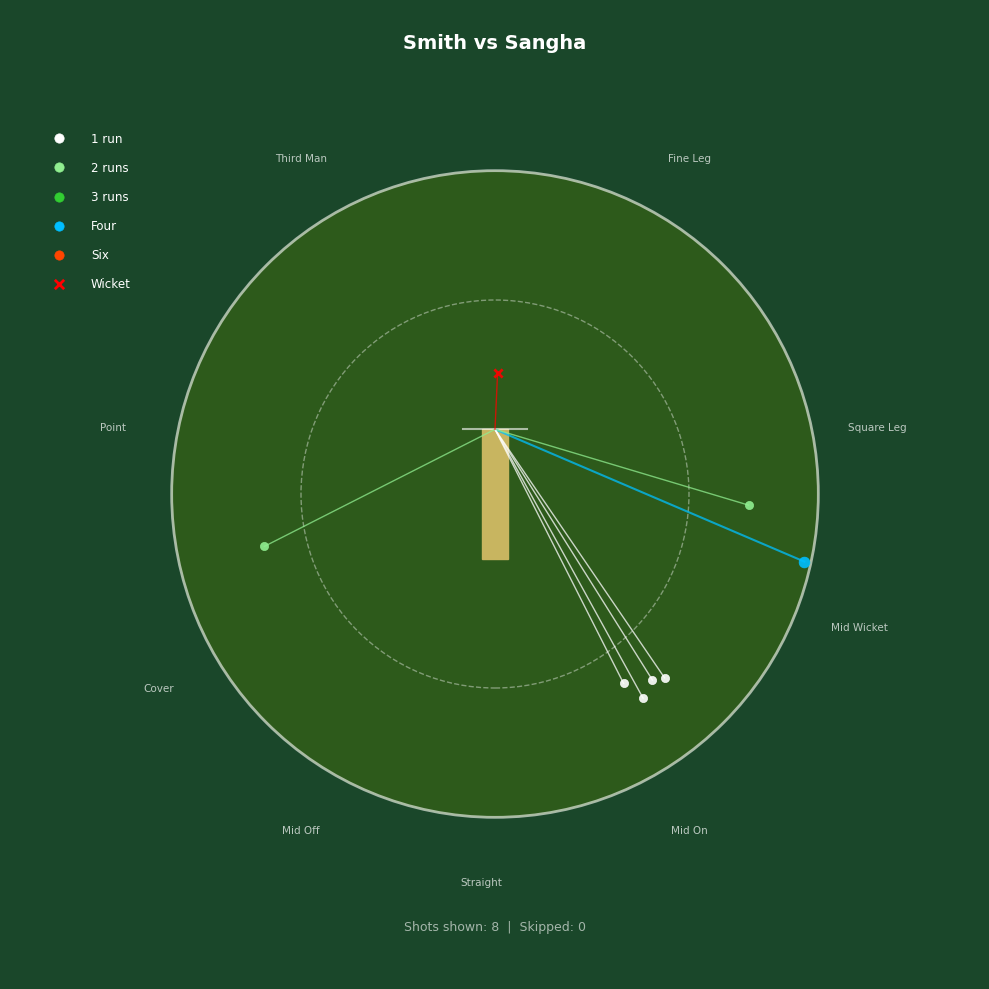

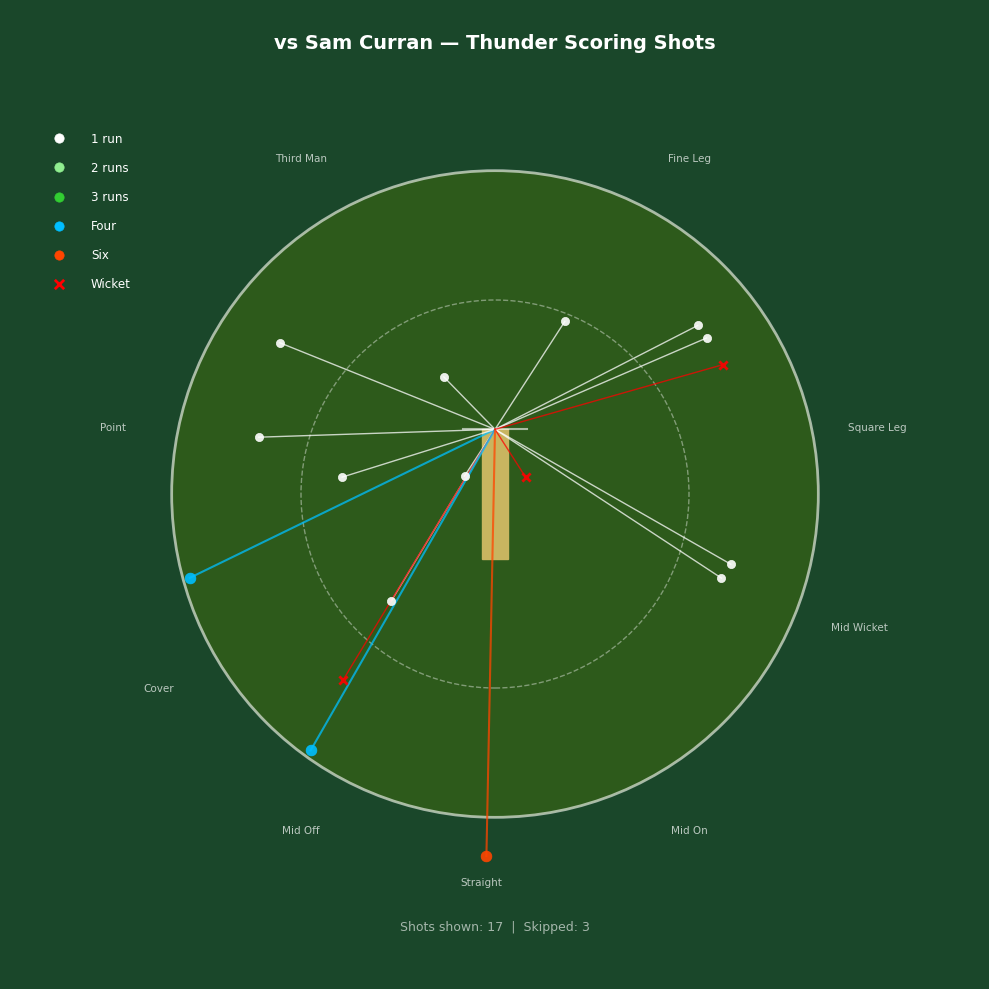

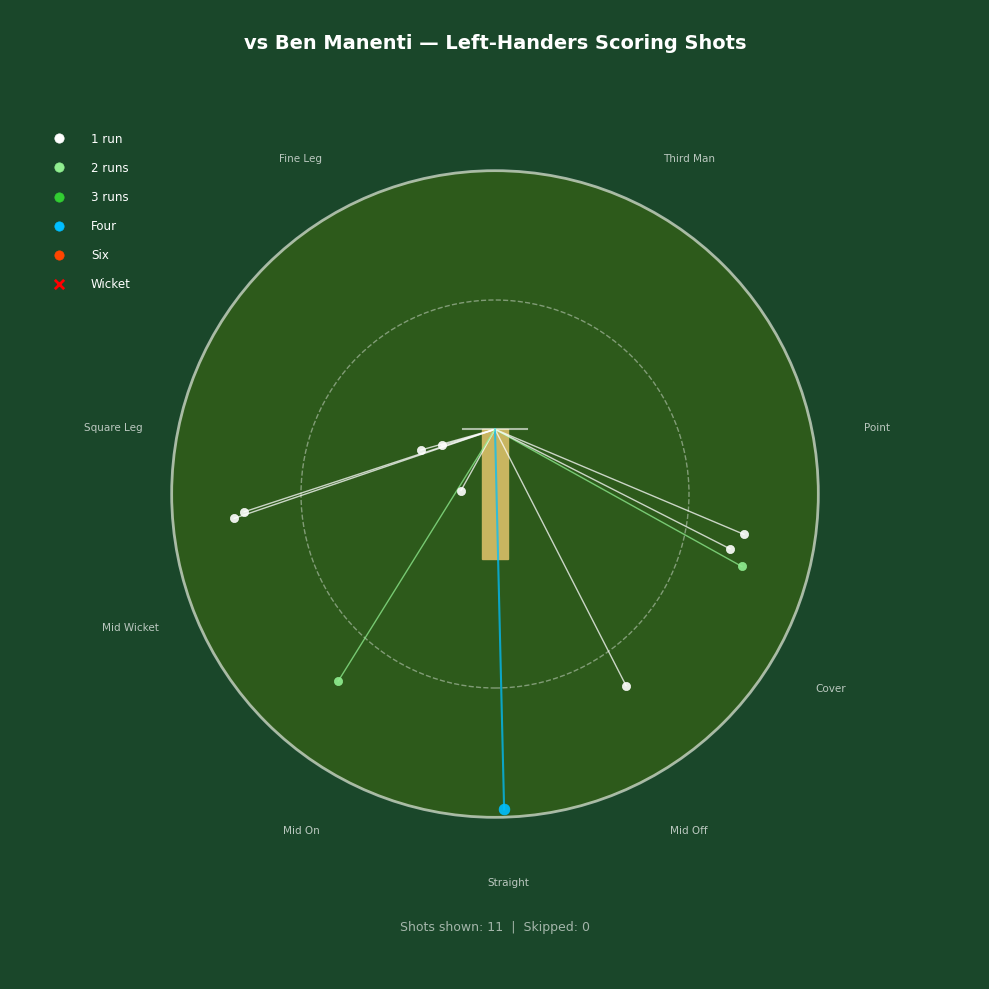

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("/Users/kushgirap/Desktop/bbl-2026-analysis/data/bbl_2026_final_coded - Sheet3.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={"batter_type": "handedness"})
df["striker"]     = df["striker"].str.strip()
df["handedness"]  = df["handedness"].str.strip()
df["is_wide"]     = df["wide"]   == "Yes"
df["is_wicket"]   = df["wicket"] == "Yes"
df["is_four"]     = df["runs_batter"] == 4
df["is_six"]      = df["runs_batter"] == 6
df["is_boundary"] = df["runs_batter"].isin([4, 6])

# ── Fielding position distance groups ─────────────────────────────────────────
DEEP = [
    "Deep Fine Leg", "Deep Backward Square Leg", "Deep Square Leg",
    "Deep Forward Square Leg", "Deep Mid Wicket", "Long On", "Long Off",
    "Deep Cover", "Deep Point", "Deep Backward Point", "Deep Forward Point",
    "Deep Third Man", "Sweeper Cover"
]
CLOSE = [
    "Silly Point", "Short Leg", "Leg Gully", "Short Mid On",
    "Short Mid Wicket", "Short Mid off", "Short Cover",
    "Keeper", "Slips", "Bowler"
]

# ── Direction angles ───────────────────────────────────────────────────────────
DIRECTION_ANGLES_RH = {
    "Fine Leg": 30, "Deep Fine Leg": 30, "Leg Gully": 45,
    "Short Leg": 50, "Backward Square Leg": 70,
    "Deep Backward Square Leg": 70, "Square Leg": 80,
    "Deep Square Leg": 80, "Forward Square Leg": 90,
    "Deep Forward Square Leg": 90, "Short Mid Wicket": 110,
    "Mid Wicket": 110, "Deep Mid Wicket": 110, "Short Mid On": 150,
    "Mid On": 150, "Long On": 150, "Straight Hit": 182,
    "Bowler": 184, "Long Off": 210, "Mid Off": 210,
    "Short Mid off": 210, "Extra Cover": 245, "Sweeper Cover": 245,
    "Short Cover": 240, "Cover": 240, "Deep Cover": 240,
    "Cover Point": 250, "Forward Point": 255, "Deep Forward Point": 255,
    "Point": 280, "Deep Point": 280, "Backward Point": 295,
    "Deep Backward Point": 295, "Gully": 310, "Silly Point": 270,
    "Slips": 320, "Third Man": 330, "Fine Third Man": 335,
    "Deep Third Man": 340, "Keeper": 360,
}

def get_angle(direction, handedness):
    cricket_angle = DIRECTION_ANGLES_RH.get(direction, None)
    if cricket_angle is None:
        return None
    if handedness == "L":
        cricket_angle = 360 - cricket_angle
    return np.radians(90 - cricket_angle)

def get_color(runs, is_wicket):
    if is_wicket:  return "#FF0000"
    if runs == 6:  return "#FF4500"
    if runs == 4:  return "#00BFFF"
    if runs == 3:  return "#32CD32"
    if runs == 2:  return "#90EE90"
    if runs == 1:  return "#FFFFFF"
    return None

def distance_to_boundary(angle_rad, origin_x=0, origin_y=0.2, radius=1.0):
    dx = np.cos(angle_rad)
    dy = np.sin(angle_rad)
    a  = dx**2 + dy**2
    b  = 2 * (origin_x * dx + origin_y * dy)
    c  = origin_x**2 + origin_y**2 - radius**2
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return radius
    t1 = (-b + np.sqrt(discriminant)) / (2*a)
    t2 = (-b - np.sqrt(discriminant)) / (2*a)
    return max(t1, t2)

# ── Draw wagon wheel ───────────────────────────────────────────────────────────
def draw_wagon_wheel(data, title="Wagon Wheel"):

    np.random.seed(42)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect("equal")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axis("off")
    fig.patch.set_facecolor("#1a472a")
    ax.set_facecolor("#1a472a")

    # Field
    ax.add_patch(plt.Circle((0,0), 1.0, color="#2d5a1b", fill=True))
    ax.add_patch(plt.Circle((0,0), 0.6, color="white", fill=False,
                             linewidth=1, linestyle="--", alpha=0.4))
    ax.add_patch(plt.Circle((0,0), 1.0, color="white", fill=False,
                             linewidth=2, alpha=0.6))
    ax.add_patch(patches.Rectangle((-0.04,-0.2), 0.08, 0.4,
                                    color="#c8b560", zorder=3))
    ax.plot([-0.1, 0.1], [0.2, 0.2],
            color="white", linewidth=1.5, alpha=0.6, zorder=4)

    # Field labels
    labels = {
        "Fine Leg": 30, "Square Leg": 80, "Mid Wicket": 110,
        "Mid On": 150, "Straight": 182, "Mid Off": 210,
        "Cover": 240, "Point": 280, "Third Man": 330,
    }

    handedness_values = data["handedness"].dropna().unique()
    is_left_handed = len(handedness_values) == 1 and handedness_values[0] == "L"

    for label, angle_deg in labels.items():
        if is_left_handed:
            angle_deg = 360 - angle_deg
        angle_rad = np.radians(90 - angle_deg)
        x = 1.2 * np.cos(angle_rad)
        y = 1.2 * np.sin(angle_rad)
        ax.text(x, y, label, ha="center", va="center",
                fontsize=7.5, color="white", alpha=0.7)

    ORIGIN_X = 0
    ORIGIN_Y = 0.2

    shots_drawn = 0
    skipped     = 0

    for _, row in data.iterrows():
        direction  = str(row.get("actual_direction", "")).strip()
        runs       = int(row.get("runs_batter", 0))
        handedness = str(row.get("handedness", "R")).strip()
        is_wicket  = bool(row.get("is_wicket", False))
        is_wide    = bool(row.get("is_wide", False))

        if is_wide:
            skipped += 1
            continue
        if runs == 0 and not is_wicket:
            continue
        if direction == "" or direction == "nan":
            skipped += 1
            continue

        angle_rad = get_angle(direction, handedness)
        if angle_rad is None:
            skipped += 1
            continue

        color = get_color(runs, is_wicket)
        if color is None:
            continue

        jitter_angle = angle_rad + np.random.uniform(-0.08, 0.08)

        if runs == 6:
            r = distance_to_boundary(jitter_angle) * 1.1
        elif runs == 4:
            r = distance_to_boundary(jitter_angle) * 0.98
        elif direction in DEEP:
            r = distance_to_boundary(jitter_angle) * 0.78
        elif direction in CLOSE:
            r = 0.20
        else:
            r = distance_to_boundary(jitter_angle) * 0.50

        if runs not in [4, 6]:
            r = r + np.random.uniform(-0.04, 0.04)

        x_end = ORIGIN_X + r * np.cos(jitter_angle)
        y_end = ORIGIN_Y + r * np.sin(jitter_angle)

        lw = 1.0 if runs <= 3 else 1.5
        ax.plot([ORIGIN_X, x_end], [ORIGIN_Y, y_end],
                color=color, linewidth=lw, alpha=0.75, zorder=4)

        sz     = 35 if runs <= 3 else 60
        marker = "x" if is_wicket else "o"
        ax.scatter(x_end, y_end, c=color, s=sz,
                   marker=marker, zorder=5, alpha=0.9,
                   linewidths=2 if is_wicket else 0.5)

        shots_drawn += 1

    # Legend
    legend_items = [
        ("#FFFFFF", "o", "1 run"),
        ("#90EE90", "o", "2 runs"),
        ("#32CD32", "o", "3 runs"),
        ("#00BFFF", "o", "Four"),
        ("#FF4500", "o", "Six"),
        ("#FF0000", "x", "Wicket"),
    ]
    for i, (col, mkr, lbl) in enumerate(legend_items):
        y_pos = 1.1 - i * 0.09
        ax.scatter([-1.35], [y_pos], c=col, s=45, marker=mkr,
                   zorder=6, linewidths=2 if mkr == "x" else 0.5)
        ax.text(-1.25, y_pos, lbl, color="white",
                fontsize=8.5, va="center")

    ax.text(0, 1.38, title, ha="center", fontsize=14,
            color="white", fontweight="bold")
    ax.text(0, -1.35,
            f"Shots shown: {shots_drawn}  |  Skipped: {skipped}",
            ha="center", fontsize=9, color="white", alpha=0.6)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').replace('—', '').strip()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# ── Filters ───────────────────────────────────────────────────────────────────

# Visual 4 — Curran containment (Thunder batting against him)
curran_bowling = df[df["bowler"] == "Sam Curran"]
draw_wagon_wheel(curran_bowling, title="vs Sam Curran — Thunder Scoring Shots")

# Visual 5 — Manenti vs Thunder left-handers
manenti_vs_lefties = df[
    (df["bowler"] == "Ben Manenti") &
    (df["handedness"] == "L")
]
draw_wagon_wheel(manenti_vs_lefties, title="vs Ben Manenti — Left-Handers Scoring Shots")

# Smith vs pace
smith_vs_pace = df[
    (df["striker"] == "Steve Smith") &
    (df["type_of_bowler"].str.contains("Fast|Medium", case=False, na=False))
]
draw_wagon_wheel(smith_vs_pace, title="Smith vs Pace")

# Smith vs Sangha
smith_vs_sangha = df[
    (df["striker"] == "Steve Smith") &
    (df["bowler"] == "Tanveer Sangha")
]
draw_wagon_wheel(smith_vs_sangha, title="Smith vs Sangha")

# Curran
curran_bowling = df[df["bowler"] == "Sam Curran"]
draw_wagon_wheel(curran_bowling, title="vs Sam Curran — Thunder Scoring Shots")

# Manenti left handers
manenti_vs_lefties = df[
    (df["bowler"] == "Ben Manenti") &
    (df["handedness"] == "L")
]
draw_wagon_wheel(manenti_vs_lefties, title="vs Ben Manenti — Left-Handers Scoring Shots")